In [1]:
try:
    import xgboost as xgb
except:
    !uv pip install xgboost
    # !uv pip install xgboost
    import xgboost as xgb

xgb.__version__

'3.2.0'

In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from tqdm import tqdm
from time import time, sleep

## -- Machine Learning --
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split, cross_val_score

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS':   5,
    'SEED':    42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --

PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e9/"
    submission = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/"
    orig = pd.read_csv(ORIG_PATH+"EV_Adoption_and_Range_Anxiety_Dataset.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e9 | EV Purchase/_ev_purchase_data/"
    submission = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"EV_Adoption_and_Range_Anxiety_Dataset.csv")

## =================================================================================

ID     = "id"
TARGET = 'Will_Buy_EV'

obj = train.select_dtypes(include=["object", "category"]).columns.tolist()

cat_cols  = [c for c in obj if c not in [TARGET, ID]]
num_cols  = [c for c in train.columns if c not in cat_cols+[TARGET, ID]]
base_cols = cat_cols + num_cols

train[TARGET] = train[TARGET].map({'No': 0, 'Yes': 1})
orig[TARGET]  = orig[TARGET].map({'No': 0, 'Yes': 1})

FEATURES = [c for c in train.columns if c not in [ID, TARGET]]

orig = orig[FEATURES+[TARGET]]
print("Total Features:", len(FEATURES))

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Nums: {len(num_cols)}")
print(f"Total Cats: {len(cat_cols)}")
print(f"Total base: {len(base_cols)}")

Total Features: 13
Train shape: (668665, 15)
Test shape: (286571, 14)
Orig shape: (10000, 14)

Total Nums: 7
Total Cats: 6
Total base: 13


In [6]:
for c in num_cols:
    orig[c] = orig[c].fillna(orig[c].median())

print(orig.isna().sum())

Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64


In [7]:
n_unique = train[base_cols].nunique().sort_values()
n_unique

Home_Charging_Possible             2
Subsidy_Available                  2
City_Type                          3
Gender                             3
Range_Anxiety_Level                3
Current_Car_Type                   4
Number_of_Cars_Owned               4
Environmental_Concern_Level        5
Charging_Stations_Near_Home       15
Charging_Stations_Near_Work       20
Age                               45
Daily_Commute_km                 805
Annual_Income_USD              13214
dtype: int64

In [8]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [9]:
def original_TE(
    orig: pd.DataFrame,
    df: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return df.copy()

    if aggs is None or len(aggs) == 0:
        return df.copy()

    X_df = df.copy()

    orig_cols = []
    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc="original_augmenting"):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_df = X_df.merge(map_df, on=col, how='left')

            orig_cols.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in orig_cols:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_df = fill_conditionally(X_df)

    return X_df, orig_cols

print("-- Data augment function ready! --")

-- Data augment function ready! --


## FEATURE ENGINEERING

In [10]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
combined = pd.concat([train, test, orig])

digits_cols = []
cols_select = ["Annual_Income_USD", "Daily_Commute_km", "Age"]

for col in cols_select:
    scaled = np.rint(combined[col] * 10**4).astype("int64")
    for k in range(-4, 4):
        dig_col = f"{col}_digit{k}"
        combined[dig_col] = (scaled // 10**(k + 4) % 10).astype('int8').astype('category')
        digits_cols.append(dig_col)

train = combined.iloc[:len(train)][list(set(base_cols + FEATURES + digits_cols)) + [TARGET]]
test = combined.iloc[len(train):len(train)+len(test)][list(set(base_cols + FEATURES + digits_cols))]
orig = combined.iloc[-len(orig):][list(set(base_cols + FEATURES + digits_cols)) + [TARGET]]

# Check nunique, and find which ones are < 2
unique_counts = train[digits_cols].nunique()
drop_cols = unique_counts[unique_counts < 2].index.tolist()

# update digit cols for keep
digits_cols = [i for i in set(digits_cols) if i not in set(drop_cols)]

# drop constant features
train = train.drop(columns=drop_cols)
test  = test.drop(columns=drop_cols)
orig  = orig.drop(columns=drop_cols)

# num_cols = list(set(num_cols + digits_cols))
# cat_cols = list(set(cat_cols + digits_cols))

print(f"Total digit features: {len(digits_cols)}\n")
del combined

train

Total digit features: 9



,Gender,Charging_Stations_Near_Work,Annual_Income_USD_digit2,Daily_Commute_km_digit-1,Daily_Commute_km,Annual_Income_USD_digit0,Range_Anxiety_Level,Home_Charging_Possible,Number_of_Cars_Owned,Age_digit0,Subsidy_Available,City_Type,Current_Car_Type,Annual_Income_USD_digit1,Age_digit1,Daily_Commute_km_digit0,Environmental_Concern_Level,Annual_Income_USD,Age,Charging_Stations_Near_Home,Daily_Commute_km_digit1,Annual_Income_USD_digit3,Will_Buy_EV
0,Male,7,8,4,23.4,7,Low,Yes,2,6,No,Suburban,Sedan,8,6,3,1.0,92887.0,66,3,2,2,0.0
1,Male,2,0,0,5.0,0,Low,Yes,1,8,No,Rural,SUV,0,3,5,4.0,30000.0,38,2,0,0,0.0
2,Female,15,3,8,36.8,9,Low,No,1,6,Yes,Urban,Sedan,8,2,6,5.0,94389.0,26,8,3,4,1.0
3,Male,9,5,7,23.7,0,Low,Yes,2,6,No,Suburban,Hatchback,8,6,3,3.0,73580.0,66,6,2,3,0.0
4,Male,3,8,8,50.8,8,Low,Yes,1,4,No,Suburban,Hatchback,9,5,0,3.0,57898.0,54,2,5,7,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,Male,6,0,4,27.4,0,Medium,No,2,0,Yes,Urban,Sedan,9,3,7,5.0,71090.0,30,5,2,1,0.0
668661,Female,4,9,0,5.0,0,Low,Yes,2,2,Yes,Suburban,SUV,9,3,5,1.0,129990.0,32,5,0,9,0.0
668662,Female,6,7,2,24.2,1,Low,Yes,1,4,Yes,Suburban,Hatchback,9,6,4,1.0,121791.0,64,5,2,1,0.0
668663,Female,0,9,7,43.7,3,Low,Yes,2,1,Yes,Rural,SUV,2,5,3,1.0,115923.0,51,0,4,5,0.0


In [11]:
INTER = []

combo_2_list = list(itertools.combinations(digits_cols, 2)) #+ cat_cols
for c1, c2 in tqdm(combo_2_list, desc='Pairwise'):
    n_col = f"Bi_{c1}_{c2}"
    train[n_col] = (train[c1].astype(str) + '_' + train[c2].astype(str)).factorize()[0]
    test[n_col]  = (test[c1].astype(str) + '_' + test[c2].astype(str)).factorize()[0]
    orig[n_col]  = (orig[c1].astype(str) + '_' + orig[c2].astype(str)).factorize()[0]
    INTER.append(n_col)

combo_3_list = list(itertools.combinations(digits_cols, 3))
for c1, c2, c3 in tqdm(combo_3_list, desc='Triplewise'):
    n_col = f"Tri_{c1}_{c2}_{c3}"
    train[n_col] = (train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)).factorize()[0]
    test[n_col]  = (test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)).factorize()[0]
    orig[n_col]  = (orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + orig[c3].astype(str)).factorize()[0]
    INTER.append(n_col)

combo_2_list2 = list(itertools.combinations(cat_cols, 2))
for c1, c2 in tqdm(combo_2_list2, desc='Pairwise'):
    n_col = f"Bi_{c1}_{c2}"
    train[n_col] = (train[c1].astype(str) + '_' + train[c2].astype(str)).factorize()[0]
    test[n_col]  = (test[c1].astype(str) + '_' + test[c2].astype(str)).factorize()[0]
    orig[n_col]  = (orig[c1].astype(str) + '_' + orig[c2].astype(str)).factorize()[0]
    INTER.append(n_col)

combo_3_list2 = list(itertools.combinations(cat_cols, 3))
for c1, c2, c3 in tqdm(combo_3_list2, desc='Triplewise'):
    n_col = f"Tri_{c1}_{c2}_{c3}"
    train[n_col] = (train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)).factorize()[0]
    test[n_col]  = (test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)).factorize()[0]
    orig[n_col]  = (orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + orig[c3].astype(str)).factorize()[0]
    INTER.append(n_col)

# combo_2_1toMany = list(itertools.product(cat_cols, digits_cols))
# for c1, c2 in tqdm(combo_2_1toMany, desc='One-to-Many'):
#     n_col = f"Bi2_{c1}_{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

print(f"Total Interaction Features: {len(INTER)}")
gc.collect()

Triplewise: 100%|██████████| 20/20 [00:08<00:00,  2.36it/s]

Total Interaction Features: 155


30

In [12]:
# ## -- Cyclic encoding --

# for df in [train, test]:
#     for p in [8, 12, 24]:
#         df[f"sleep_hours_sin_{p}"] = np.sin(2 * np.pi * df["sleep_hours"] / p).astype("float32")
#         df[f"sleep_hours_cos_{p}"] = np.cos(2 * np.pi * df["sleep_hours"] / p).astype("float32")

In [13]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Total Features:", len(FEATURES))

combined = pd.concat([train, test, orig])
## ------------------------------------------------------------
## -- Duplicate Nums as Cats --
nums_to_cats = []
for c in tqdm(num_cols, desc="nums_to_cats"):
    n = f"{c}_cat"
    combined[n] = combined[c].factorize()[0]
    # combined[n] = combined[n].astype('category')
    nums_to_cats.append(n)
FEATURES = list(set(FEATURES + nums_to_cats))
## ------------------------------------------------------------
# -- Factorize cat_cols --
for c in tqdm(cat_cols+INTER, desc="factorize_cats"): # +new_cats
    combined[c] = combined[c].factorize()[0]

for c in tqdm(cat_cols, desc="categorize_cats"):
    combined[c] = combined[c].astype("category")

train = combined.iloc[:len(train)][FEATURES+[TARGET]]
test  = combined.iloc[len(train):len(train)+len(test)][FEATURES]
orig  = combined.iloc[len(train)+len(test):]

del combined
print("Label encoding complete!")

train

Total Features: 177


categorize_cats: 100%|██████████| 6/6 [00:00<00:00, 86.37it/s]


Label encoding complete!


,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Age_digit0,Tri_Age_digit0_Daily_Commute_km_digit0_Annual_Income_USD_digit3,Tri_Daily_Commute_km_digit-1_Annual_Income_USD_digit0_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit0_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit0_Annual_Income_USD_digit1_Annual_Income_USD_digit3,Tri_Daily_Commute_km_digit-1_Age_digit0_Age_digit1,Tri_Annual_Income_USD_digit0_Annual_Income_USD_digit1_Age_digit1,Tri_Current_Car_Type_Subsidy_Available_Range_Anxiety_Level,Annual_Income_USD_digit0,Bi_City_Type_Home_Charging_Possible,Tri_Annual_Income_USD_digit2_Age_digit0_Daily_Commute_km_digit0,Home_Charging_Possible,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit1,Bi_Current_Car_Type_Home_Charging_Possible,Age_digit0,Bi_Age_digit1_Annual_Income_USD_digit3,Bi_Current_Car_Type_Subsidy_Available,Bi_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Tri_Age_digit1_Daily_Commute_km_digit1_Annual_Income_USD_digit3,Bi_Daily_Commute_km_digit0_Annual_Income_USD_digit3,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Daily_Commute_km_digit1,Tri_Daily_Commute_km_digit-1_Annual_Income_USD_digit1_Age_digit1,Annual_Income_USD_digit1,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit0_Age_digit1_Annual_Income_USD_digit3,Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit1_Age_digit1,Bi_Subsidy_Available_Range_Anxiety_Level,Bi_Annual_Income_USD_digit1_Annual_Income_USD_digit3,Tri_Annual_Income_USD_digit2_Age_digit0_Annual_Income_USD_digit1,Bi_Age_digit0_Age_digit1,Tri_Daily_Commute_km_digit-1_Age_digit0_Annual_Income_USD_digit3,Age_digit1,Tri_Current_Car_Type_Home_Charging_Possible_Range_Anxiety_Level,Bi_Gender_Home_Charging_Possible,Daily_Commute_km_digit0,Age,Charging_Stations_Near_Home,Daily_Commute_km_digit1,Tri_Daily_Commute_km_digit-1_Annual_Income_USD_digit0_Daily_Commute_km_digit0,Tri_Daily_Commute_km_digit-1_Age_digit0_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit1_Annual_Income_USD_digit3,Age_cat,Tri_Annual_Income_USD_digit2_Age_digit0_Annual_Income_USD_digit3,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit0,Tri_Daily_Commute_km_digit-1_Annual_Income_USD_digit0_Age_digit0,Gender,Tri_Annual_Income_USD_digit0_Age_digit1_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit0_Daily_Commute_km_digit0_Daily_Commute_km_digit1,Daily_Commute_km_digit-1,Tri_Age_digit0_Age_digit1_Daily_Commute_km_digit1,Annual_Income_USD_cat,Bi_Daily_Commute_km_digit0_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit0_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit0_Annual_Income_USD_digit3,Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit1_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit2_Age_digit0,Tri_Age_digit0_Age_digit1_Daily_Commute_km_digit0,Tri_Gender_Home_Charging_Possible_Range_Anxiety_Level,Number_of_Cars_Owned,Tri_Gender_City_Type_Subsidy_Available,Bi_Annual_Income_USD_digit0_Age_digit1,Tri_City_Type_Current_Car_Type_Home_Charging_Possible,Tri_Annual_Income_USD_digit0_Age_digit0_Annual_Income_USD_digit3,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit3,Bi_Annual_Income_USD_digit1_Age_digit1,Tri_City_Type_Current_Car_Type_Subsidy_Available,Tri_Daily_Commute_km_digit-1_Annual_Income_USD_digit0_Annual_Income_USD_digit1,Tri_Gender_Subsidy_Available_Range_Anxiety_Level,City_Type,Tri_Daily_Commute_km_digit-1_Daily_Commute_km_digit0_Daily_Commute_km_digit1,Bi_Daily_Commute_km_digit-1_Daily_Commute_km_digit1,Tri_Current_Car_Type_Home_Charging_Possible_Subsidy_Available,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit0_Age_digit0_Age_digit1,Tri_Annual_Income_USD_digit0_Age_digit0_Daily_Commute_km_digit1,Tri_Gender_City_Type_Home_Charging_Possible,Daily_Commute_km_cat,Bi_Daily_Commute_km_digit-1_Annual_Income_USD_digit0,Tri_Annual_Income_USD_digit0_Age_di

In [14]:
def feat_eng(df1, trn=True):
    df = df1.copy()
    # Arithmetic interaction
    df['_Daily_Commute_km_/_Age'] = (df['Daily_Commute_km'] / (df['Age'] + 1)).astype('float32')

    df['_Income_//_10_'] = (df['Annual_Income_USD'] // 10).astype('float32')
    df['_Income_//_100_'] = (df['Annual_Income_USD'] // 100).astype('float32')
    df['_Income_//_1000_'] = (df['Annual_Income_USD'] // 1000).astype('float32')
    # df['gt_179k_lock'] = (df['Annual_Income_USD'] >= 179_000).astype('int8')

    # log_cols = []
    # for col in ['Annual_Income_USD', 'Daily_Commute_km']:
    #     log_name = f"_log_{col}"
    #     df[log_name] = np.log(df[col])
    #     log_cols.append(log_name)

    nm_cols = ['_Daily_Commute_km_/_Age'] # + log_cols
    ct_cols = ['_Income_//_10_', '_Income_//_100_', '_Income_//_1000_'] #[] 

    if trn:
        return df, nm_cols, ct_cols
    else:
        return df

train, nm_cols, ct_cols = feat_eng(train)
test = feat_eng(test, trn=False)
orig = feat_eng(orig, trn=False)

num_cols = list(set(num_cols + nm_cols))
# cat_cols = list(set(cat_cols + ct_cols))

train

,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Age_digit0,Tri_Age_digit0_Daily_Commute_km_digit0_Annual_Income_USD_digit3,Tri_Daily_Commute_km_digit-1_Annual_Income_USD_digit0_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit0_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit0_Annual_Income_USD_digit1_Annual_Income_USD_digit3,Tri_Daily_Commute_km_digit-1_Age_digit0_Age_digit1,Tri_Annual_Income_USD_digit0_Annual_Income_USD_digit1_Age_digit1,Tri_Current_Car_Type_Subsidy_Available_Range_Anxiety_Level,Annual_Income_USD_digit0,Bi_City_Type_Home_Charging_Possible,Tri_Annual_Income_USD_digit2_Age_digit0_Daily_Commute_km_digit0,Home_Charging_Possible,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit1,Bi_Current_Car_Type_Home_Charging_Possible,Age_digit0,Bi_Age_digit1_Annual_Income_USD_digit3,Bi_Current_Car_Type_Subsidy_Available,Bi_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Tri_Age_digit1_Daily_Commute_km_digit1_Annual_Income_USD_digit3,Bi_Daily_Commute_km_digit0_Annual_Income_USD_digit3,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Daily_Commute_km_digit1,Tri_Daily_Commute_km_digit-1_Annual_Income_USD_digit1_Age_digit1,Annual_Income_USD_digit1,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit0_Age_digit1_Annual_Income_USD_digit3,Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit1_Age_digit1,Bi_Subsidy_Available_Range_Anxiety_Level,Bi_Annual_Income_USD_digit1_Annual_Income_USD_digit3,Tri_Annual_Income_USD_digit2_Age_digit0_Annual_Income_USD_digit1,Bi_Age_digit0_Age_digit1,Tri_Daily_Commute_km_digit-1_Age_digit0_Annual_Income_USD_digit3,Age_digit1,Tri_Current_Car_Type_Home_Charging_Possible_Range_Anxiety_Level,Bi_Gender_Home_Charging_Possible,Daily_Commute_km_digit0,Age,Charging_Stations_Near_Home,Daily_Commute_km_digit1,Tri_Daily_Commute_km_digit-1_Annual_Income_USD_digit0_Daily_Commute_km_digit0,Tri_Daily_Commute_km_digit-1_Age_digit0_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit1_Annual_Income_USD_digit3,Age_cat,Tri_Annual_Income_USD_digit2_Age_digit0_Annual_Income_USD_digit3,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit0,Tri_Daily_Commute_km_digit-1_Annual_Income_USD_digit0_Age_digit0,Gender,Tri_Annual_Income_USD_digit0_Age_digit1_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit0_Daily_Commute_km_digit0_Daily_Commute_km_digit1,Daily_Commute_km_digit-1,Tri_Age_digit0_Age_digit1_Daily_Commute_km_digit1,Annual_Income_USD_cat,Bi_Daily_Commute_km_digit0_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit0_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit0_Annual_Income_USD_digit3,Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit1_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit2_Age_digit0,Tri_Age_digit0_Age_digit1_Daily_Commute_km_digit0,Tri_Gender_Home_Charging_Possible_Range_Anxiety_Level,Number_of_Cars_Owned,Tri_Gender_City_Type_Subsidy_Available,Bi_Annual_Income_USD_digit0_Age_digit1,Tri_City_Type_Current_Car_Type_Home_Charging_Possible,Tri_Annual_Income_USD_digit0_Age_digit0_Annual_Income_USD_digit3,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit3,Bi_Annual_Income_USD_digit1_Age_digit1,Tri_City_Type_Current_Car_Type_Subsidy_Available,Tri_Daily_Commute_km_digit-1_Annual_Income_USD_digit0_Annual_Income_USD_digit1,Tri_Gender_Subsidy_Available_Range_Anxiety_Level,City_Type,Tri_Daily_Commute_km_digit-1_Daily_Commute_km_digit0_Daily_Commute_km_digit1,Bi_Daily_Commute_km_digit-1_Daily_Commute_km_digit1,Tri_Current_Car_Type_Home_Charging_Possible_Subsidy_Available,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit0_Age_digit0_Age_digit1,Tri_Annual_Income_USD_digit0_Age_digit0_Daily_Commute_km_digit1,Tri_Gender_City_Type_Home_Charging_Possible,Daily_Commute_km_cat,Bi_Daily_Commute_km_digit-1_Annual_Income_USD_digit0,Tri_Annual_Income_USD_digit0_Age_di

In [15]:
# ## -- "mean", "median", "count", "std", "skew", "nunique", "max", "min"
# orig_aggs = ["median", "count", "std"]

# train, orig_cols = original_TE(
#     orig,
#     train,
#     features=base_cols,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# test, _ = original_TE(
#     orig,
#     test,
#     features=base_cols,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# train[orig_cols][:10].T

In [16]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         if df[c].dtype == np.int64: 
#             ## -- Downcast Integer type ---
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         elif df[c].dtype == np.float64:
#             ## -- Downcast Float type -----
#             if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#                 df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test  = reduce_memory(test)
# orig  = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [17]:
_ = [c for c in train.columns if c not in [ID, TARGET]]
FEATURES = list(set(_))

print("Total Features:", len(FEATURES))

train

Total Features: 188


,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Age_digit0,Tri_Age_digit0_Daily_Commute_km_digit0_Annual_Income_USD_digit3,Tri_Daily_Commute_km_digit-1_Annual_Income_USD_digit0_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit0_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit0_Annual_Income_USD_digit1_Annual_Income_USD_digit3,Tri_Daily_Commute_km_digit-1_Age_digit0_Age_digit1,Tri_Annual_Income_USD_digit0_Annual_Income_USD_digit1_Age_digit1,Tri_Current_Car_Type_Subsidy_Available_Range_Anxiety_Level,Annual_Income_USD_digit0,Bi_City_Type_Home_Charging_Possible,Tri_Annual_Income_USD_digit2_Age_digit0_Daily_Commute_km_digit0,Home_Charging_Possible,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit1,Bi_Current_Car_Type_Home_Charging_Possible,Age_digit0,Bi_Age_digit1_Annual_Income_USD_digit3,Bi_Current_Car_Type_Subsidy_Available,Bi_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Tri_Age_digit1_Daily_Commute_km_digit1_Annual_Income_USD_digit3,Bi_Daily_Commute_km_digit0_Annual_Income_USD_digit3,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Daily_Commute_km_digit1,Tri_Daily_Commute_km_digit-1_Annual_Income_USD_digit1_Age_digit1,Annual_Income_USD_digit1,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit0_Age_digit1_Annual_Income_USD_digit3,Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit1_Age_digit1,Bi_Subsidy_Available_Range_Anxiety_Level,Bi_Annual_Income_USD_digit1_Annual_Income_USD_digit3,Tri_Annual_Income_USD_digit2_Age_digit0_Annual_Income_USD_digit1,Bi_Age_digit0_Age_digit1,Tri_Daily_Commute_km_digit-1_Age_digit0_Annual_Income_USD_digit3,Age_digit1,Tri_Current_Car_Type_Home_Charging_Possible_Range_Anxiety_Level,Bi_Gender_Home_Charging_Possible,Daily_Commute_km_digit0,Age,Charging_Stations_Near_Home,Daily_Commute_km_digit1,Tri_Daily_Commute_km_digit-1_Annual_Income_USD_digit0_Daily_Commute_km_digit0,Tri_Daily_Commute_km_digit-1_Age_digit0_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit1_Annual_Income_USD_digit3,Age_cat,Tri_Annual_Income_USD_digit2_Age_digit0_Annual_Income_USD_digit3,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit0,Tri_Daily_Commute_km_digit-1_Annual_Income_USD_digit0_Age_digit0,Gender,Tri_Annual_Income_USD_digit0_Age_digit1_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit0_Daily_Commute_km_digit0_Daily_Commute_km_digit1,Daily_Commute_km_digit-1,Tri_Age_digit0_Age_digit1_Daily_Commute_km_digit1,Annual_Income_USD_cat,Bi_Daily_Commute_km_digit0_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit0_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit0_Annual_Income_USD_digit3,Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit1_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit2_Age_digit0,Tri_Age_digit0_Age_digit1_Daily_Commute_km_digit0,Tri_Gender_Home_Charging_Possible_Range_Anxiety_Level,Number_of_Cars_Owned,Tri_Gender_City_Type_Subsidy_Available,Bi_Annual_Income_USD_digit0_Age_digit1,Tri_City_Type_Current_Car_Type_Home_Charging_Possible,Tri_Annual_Income_USD_digit0_Age_digit0_Annual_Income_USD_digit3,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit3,Bi_Annual_Income_USD_digit1_Age_digit1,Tri_City_Type_Current_Car_Type_Subsidy_Available,Tri_Daily_Commute_km_digit-1_Annual_Income_USD_digit0_Annual_Income_USD_digit1,Tri_Gender_Subsidy_Available_Range_Anxiety_Level,City_Type,Tri_Daily_Commute_km_digit-1_Daily_Commute_km_digit0_Daily_Commute_km_digit1,Bi_Daily_Commute_km_digit-1_Daily_Commute_km_digit1,Tri_Current_Car_Type_Home_Charging_Possible_Subsidy_Available,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit0_Age_digit0_Age_digit1,Tri_Annual_Income_USD_digit0_Age_digit0_Daily_Commute_km_digit1,Tri_Gender_City_Type_Home_Charging_Possible,Daily_Commute_km_cat,Bi_Daily_Commute_km_digit-1_Annual_Income_USD_digit0,Tri_Annual_Income_USD_digit0_Age_di

# ML TRAINING

In [18]:
def Trainer_CV(
    model_name, params, train_df, test_df, features, target, kfold, cat_cols,
    use_orig=False, use_te=False, early_stop=100, print_every=200,
):
    print(f"\n===== Starting CV: {model_name} | {get_system_info()} =====")
    t0 = time()

    oof_preds  = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))

    fold_scores = []
    feat_importances = []

    # Handle optional original table aggregations securely if flags enable them
    if use_orig and "original_TE" in globals():
        feats = features.copy()
        aggs_ = ["mean"]  #, "count", "std", "skew"
        X_tr, orig_cols = original_TE(
            orig, train_df, target=TARGET, features=base_cols, aggs=aggs_, #fill_nan=True
        )
        x_test, _ = original_TE(
            orig, test_df, target=TARGET, features=base_cols, aggs=aggs_, #fill_nan=True
        )
        feats.extend(orig_cols)
        X = X_tr[feats]
        y = X_tr[target].astype("int8")
        X_ts = x_test[feats]
    else:
        X = train_df[features]
        y = train_df[target].astype("int8")
        X_ts = test[features]
    # ------------------------------------------------------------------------------------
    if 'group_kf' in model_name:
        print("Using GROUP splits --- ")
        strat_id = y.astype(str) + '__' + X['Year'].astype(str)
        splitter = kfold.split(X, strat_id)
    else:
        print("Using REGULAR splits --- ")
        splitter = kfold.split(X, y)

    for idx, (train_idx, val_idx) in enumerate(splitter, 1):
        print(f"\n+++++ FOLD {idx}/{kfold.n_splits}", end=" | ")

        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = X_ts.copy()

        # ## -- OPTION A: CONCATENATE ORIGINAL DATA --
        # if use_orig:
        #     X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        #     y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        #     # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        if use_te:
            te_cols = nums_to_cats + INTER + ct_cols
            print(f"Target Encoding {len(te_cols)} features...", end=" | ")
            TE = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
            X_train = TE.fit_transform(X_train, y_train)
            X_valid = TE.transform(X_valid)
            X_test  = TE.transform(X_test)

        # combined = pd.concat([X_train, X_valid, X_test])
        # for c in cat_cols:
        #     combined[c] = combined[c].factorize()[0]
        #     combined[c] = combined[c].astype('category')
        # X_train = combined.iloc[:len(X_train)]
        # X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        # X_test  = combined.iloc[len(X_train)+len(X_valid):]

        print(f"shape: {X_train.shape}")
        if idx == 1:
            display(X_train.head(3))

        # -------------------------------------------------------------------------------
        # dtrain = xgb.DMatrix(X_train, y_train, enable_categorical=True)
        # dval   = xgb.DMatrix(X_valid, y_valid, enable_categorical=True)
        # dtest  = xgb.DMatrix(X_test, enable_categorical=True)
        # model = xgb.train(
        #     params,
        #     dtrain,
        #     num_boost_round=15_000,
        #     evals=[(dtrain, 'train'), (dval, 'valid')],
        #     early_stopping_rounds=early_stop,
        #     verbose_eval=print_every,
        # )
        # ## -- Predictions --
        # oof_preds[val_idx] = model.predict(dval, iteration_range=(0, model.best_iteration+1))
        # test_preds += model.predict(dtest, iteration_range=(0, model.best_iteration+1)) / kfold.n_splits
        # -------------------------------------------------------------------------------
        model = xgb.XGBClassifier(**params, early_stopping_rounds=early_stop)
        model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=print_every)
        
        feat_importances.append(model.feature_importances_.ravel())
        
        ## -- Predictions --
        oof_preds[val_idx] = model.predict_proba(X_valid)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / kfold.n_splits

        ## -- Calculate fold score --
        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)

        print(f"{CFG['YELLOW']} • Fold {idx} AUC: {fold_score:.6f}{CFG['RESET']}")

        ## -- Clean up memory --
        # del dtrain, dval, dtest
        # gc.collect()

    # ## -- Average the test predictions --
    # test_preds /= kfold.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name} | {X_train.shape}")
    print("==================================================")
    for i, s in enumerate(fold_scores, 1):
        print(f" • Fold {i} AUC: {s:.6f}")

    ## -- Calculate out-of-fold Score --
    oof_score = np.round(roc_auc_score(y, oof_preds), 6)

    print("-------------------------------------------------|")
    print(f"Overall AUC: {oof_score}")
    print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f"{(time()-t0)/60:.2f} mins\n")

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_score,
        'model': model,
        'importances': feat_importances,
        'val_data': [X_valid, y_valid],
    }

print("⚙️ Trainer function ready ⚙️")

⚙️ Trainer function ready ⚙️


In [19]:
## -- Plot Feature Importances --
def plot_feature_importances(num_models=1, max_cols=10):
    for i, (k, v) in enumerate(all_predictions.items()):
        for j, (x, y) in enumerate(v.items()):
            if x == 'model':
                display_limit = 20
                if max_cols > display_limit:
                    print("⚠️ Display limit is 20 features")

                _, axs = plt.subplots(1, 2, figsize=(16, min(10, max_cols)*0.8))

                ## -- Feature Gain --
                xgb.plot_importance(
                    y, importance_type='gain', max_num_features=max_cols,
                    ax=axs[0], height=0.5, show_values=False,
                )
                axs[0].set_title("Average gain")
                axs[0].set_ylabel('Feature_id', fontdict={'size': 12})

                ## -- Feature Weight --
                xgb.plot_importance(y, importance_type='weight', max_num_features=max_cols,
                                    ax=axs[1], height=0.5, show_values=False,)
                axs[1].set_title("Feature weights")
                axs[1].set_ylabel("")

                for ax in axs:
                    ax.set_xlabel("Score", fontdict={'size': 12})
                    ax.spines['top'].set_visible(False)
                    ax.spines['right'].set_visible(False)

                plt.suptitle(f"{k}_{str(all_scores[k]).split('.')[1]}", fontsize=15, fontweight='bold')
                plt.tight_layout()
                plt.show()
                print()

print("📊 Feature Importance plot function ready!")

📊 Feature Importance plot function ready!


In [20]:
all_predictions = {}

MULTI_SEEDS = [42, 777, 1234, 24611, 0]
ALL_CATS = cat_cols 

FOLDS = 10
USE_FULL_TRAIN = True

skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

x_sample, x_sample2 = train_test_split(train, train_size=300_000, stratify=train[TARGET], random_state=0)
train_X = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True)

train_X

,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Age_digit0,Tri_Age_digit0_Daily_Commute_km_digit0_Annual_Income_USD_digit3,Tri_Daily_Commute_km_digit-1_Annual_Income_USD_digit0_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit0_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit0_Annual_Income_USD_digit1_Annual_Income_USD_digit3,Tri_Daily_Commute_km_digit-1_Age_digit0_Age_digit1,Tri_Annual_Income_USD_digit0_Annual_Income_USD_digit1_Age_digit1,Tri_Current_Car_Type_Subsidy_Available_Range_Anxiety_Level,Annual_Income_USD_digit0,Bi_City_Type_Home_Charging_Possible,Tri_Annual_Income_USD_digit2_Age_digit0_Daily_Commute_km_digit0,Home_Charging_Possible,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit1,Bi_Current_Car_Type_Home_Charging_Possible,Age_digit0,Bi_Age_digit1_Annual_Income_USD_digit3,Bi_Current_Car_Type_Subsidy_Available,Bi_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Tri_Age_digit1_Daily_Commute_km_digit1_Annual_Income_USD_digit3,Bi_Daily_Commute_km_digit0_Annual_Income_USD_digit3,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Daily_Commute_km_digit1,Tri_Daily_Commute_km_digit-1_Annual_Income_USD_digit1_Age_digit1,Annual_Income_USD_digit1,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit0_Age_digit1_Annual_Income_USD_digit3,Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit1_Age_digit1,Bi_Subsidy_Available_Range_Anxiety_Level,Bi_Annual_Income_USD_digit1_Annual_Income_USD_digit3,Tri_Annual_Income_USD_digit2_Age_digit0_Annual_Income_USD_digit1,Bi_Age_digit0_Age_digit1,Tri_Daily_Commute_km_digit-1_Age_digit0_Annual_Income_USD_digit3,Age_digit1,Tri_Current_Car_Type_Home_Charging_Possible_Range_Anxiety_Level,Bi_Gender_Home_Charging_Possible,Daily_Commute_km_digit0,Age,Charging_Stations_Near_Home,Daily_Commute_km_digit1,Tri_Daily_Commute_km_digit-1_Annual_Income_USD_digit0_Daily_Commute_km_digit0,Tri_Daily_Commute_km_digit-1_Age_digit0_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit1_Annual_Income_USD_digit3,Age_cat,Tri_Annual_Income_USD_digit2_Age_digit0_Annual_Income_USD_digit3,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit0,Tri_Daily_Commute_km_digit-1_Annual_Income_USD_digit0_Age_digit0,Gender,Tri_Annual_Income_USD_digit0_Age_digit1_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit0_Daily_Commute_km_digit0_Daily_Commute_km_digit1,Daily_Commute_km_digit-1,Tri_Age_digit0_Age_digit1_Daily_Commute_km_digit1,Annual_Income_USD_cat,Bi_Daily_Commute_km_digit0_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit0_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit0_Annual_Income_USD_digit3,Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit1_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit2_Age_digit0,Tri_Age_digit0_Age_digit1_Daily_Commute_km_digit0,Tri_Gender_Home_Charging_Possible_Range_Anxiety_Level,Number_of_Cars_Owned,Tri_Gender_City_Type_Subsidy_Available,Bi_Annual_Income_USD_digit0_Age_digit1,Tri_City_Type_Current_Car_Type_Home_Charging_Possible,Tri_Annual_Income_USD_digit0_Age_digit0_Annual_Income_USD_digit3,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit3,Bi_Annual_Income_USD_digit1_Age_digit1,Tri_City_Type_Current_Car_Type_Subsidy_Available,Tri_Daily_Commute_km_digit-1_Annual_Income_USD_digit0_Annual_Income_USD_digit1,Tri_Gender_Subsidy_Available_Range_Anxiety_Level,City_Type,Tri_Daily_Commute_km_digit-1_Daily_Commute_km_digit0_Daily_Commute_km_digit1,Bi_Daily_Commute_km_digit-1_Daily_Commute_km_digit1,Tri_Current_Car_Type_Home_Charging_Possible_Subsidy_Available,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit0_Age_digit0_Age_digit1,Tri_Annual_Income_USD_digit0_Age_digit0_Daily_Commute_km_digit1,Tri_Gender_City_Type_Home_Charging_Possible,Daily_Commute_km_cat,Bi_Daily_Commute_km_digit-1_Annual_Income_USD_digit0,Tri_Annual_Income_USD_digit0_Age_di

#### Summary (Order) Checklist
---
1) **GBDT & GRADIENT**
* [Pair 1: Model Complexity] -> (`max_depth` + `min_child_weight`)
* [Pair 2: Randomization]    -> (`subsample` + `colsample_bytree`)
* [Single: Regularization]   -> (`alpha` / `lambda` / `gamma`)
* [Single: Final Polish]     -> (`Lower` `learning_rate`)
---
2) **LOSSGUIDE**
* [Pair 1: Leaf Complexity] -> (`max_leaves` + `max_depth`)
* [Single: Regularization]  -> (`min_child_weight`)
* [Pair 2: Randomization]   -> (`subsample` + `colsample_bytree`)
* [Pair 3: Regularization]  -> (`alpha` / `lambda` / `gamma`)
* [Single: Regularization]  -> (`gamma`)
* [Single: Final Polish]    -> (`Lower` `learning_rate`)

In [21]:
# ## ===== PARAMETER ADJUSTMENT TRAINER =====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# # if all_predictions:
# #     all_predictions.clear()

# OUT_LOOP = [10]
# INN_LOOP = [10]
# p_name   = ['l1', 'l2']

# for i, outer in enumerate(OUT_LOOP):
#     for j, inner in enumerate(INN_LOOP):
#         print(f" >>> {p_name[0]} {i+1}/{len(OUT_LOOP)} -with- {p_name[1]} {j+1}/{len(INN_LOOP)} <<<")
#         trial_params = {
#             "sampling_method": "gradient_based",
#             # # ----------------------------------
#             # "grow_policy": "lossguide",
#             # "max_leaves": 16,
#             "max_depth": 2, # 0 if lossguide
#             # ------------------------------------
#             "objective": "binary:logistic",
#             "eval_metric": "auc",
#             "enable_categorical": True,
#             "n_estimators": 15_000,
#             # "learning_rate": outer,
#             "subsample": 0.8,
#             "colsample_bytree": 0.8,
#             "reg_alpha": 10.0,
#             "reg_lambda": 1.0,
#             "min_child_weight": 60,
#             # "max_bins": outer,
#             # "scale_pos_weight": sum(train[TARGET] == 0) / sum(train[TARGET] == 1),
#             "random_state": CFG['SEED'],
#             "verbosity": 0,
#             "n_jobs": -1,
#             "device": "cuda" if torch.cuda.is_available() else "cpu",
#         }

#         n = "_" + f"{p_name[0]}={OUT_LOOP[i]}__{p_name[1]}={INN_LOOP[j]}_"
#         all_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=trial_params,
#             train_df=train_X,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kfold=skf,
#             cat_cols=ALL_CATS,
#             use_orig=True,
#             # early_stop=100,
#             # print_every=500,
#         )

# print(f"\n===== ☑️ Complete! {len(all_predictions)} model(s) =====\n")

In [22]:
# all_scores = {}

# for i, (k, v) in enumerate(all_predictions.items()):
#     for x, y in v.items():
#         if x == "score":
#             all_scores[k] = y

# plt.figure(figsize=(16, 6))
# ax1 = sns.lineplot([*all_scores.values()], marker="s")

# y_add = 1e-6

# for i, s1 in enumerate([*all_scores.values()]):
#     ax1.text(float(i), s1+y_add, s1, ha="center", va="baseline")

# # plt.ylim((0.94, 0.955))
# plt.legend(loc="best")
# plt.xticks(range(len(all_scores)), [*all_scores.keys()], rotation=90)
# plt.title("-- Model scores --", fontdict={"weight": "semibold", "size": 15})

# plt.tight_layout()
# plt.show()

In [23]:
# ## -- Plot feature importances --
# plot_feature_importances(num_models=1, max_cols=20)

### OPTUNA SEARCH

In [24]:
# try:
#     import optuna
# except:
#     !uv pip install optuna
#     import optuna

In [25]:
# def objective(trial):
#     params = {
#         # -------------------------------------------------
#         # "sampling_method": "gradient_based",
#         "max_depth": trial.suggest_int("max_depth", 3, 10),
#         # -------------------------------------------------
#         # "grow_policy": "lossguide",
#         # "max_leaves": trial.suggest_int("max_leaves", 32, 64, step=32),
#         # "max_depth": 0,
#         # -------------------------------------------------
#         # Core Tree Booster Parameters
#         "min_child_weight": trial.suggest_int("min_weight", 1, 50),
#         "max_bins": trial.suggest_int("max_bins", 256, 1024, step=256),

#         # SRegularization Parameters (Staves off overfitting)
#         "subsample": trial.suggest_float("subsample", 0.6, 1.0, step=0.05),
#         "colsample_bytree": trial.suggest_float("colsample", 0.3, 1.0, step=0.05),
#         "reg_alpha": trial.suggest_float("alpha", 1e-5, 10.0, log=True),
#         "reg_lambda": trial.suggest_float("lambda", 1e-5, 10.0, log=True),

#         "learning_rate": 0.05,
#         # "learning_rate": trial.suggest_float("lr", 0.05),

#         # Structural Settings
#         "objective": "binary:logistic",
#         "eval_metric": "auc",
#         "enable_categorical": True,
#         "n_estimators": 10_000,
#         "random_state": 101,
#         "n_jobs": -1,
#         "device": "cuda" if torch.cuda.is_available() else "cpu",
#     }

#     n = "Optuna"

#     all_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=params,
#         train_df=train_X,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kfold=skf,
#         cat_cols=ALL_CATS,
#         use_te=True,
#         use_orig=True,
#         early_stop=100,
#         print_every=1000,
#     )
#     return all_predictions[n]["score"]

# print("Optuna search ready!")

# # # 3. Create the study and run optimization
# # if __name__ == "__main__":
# #     # TPE Sampler (Bayesian Optimization) is used by default
# #     study = optuna.create_study(direction="maximize")

# #     # Run optimization for 50 trials
# #     study.optimize(objective, n_trials=50, show_progress_bar=True)

# #     # Print out results
# #     print("\n--- Optimization Complete ---")
# #     print(f"Best Trial ROC-AUC Score: {study.best_value:.4f}")
# #     print("Best Hyperparameters:")
# #     for key, value in study.best_params.items():
# #         print(f"  {key}: {value}")

# #     # 4. Train the final model using the absolute best parameters
# #     best_model = xgb.XGBClassifier(**study.best_params, tree_method="hist", random_state=42)
# #     best_model.fit(X, y)


In [26]:
# # 3. Create the study and run optimization
# study = optuna.create_study(direction="maximize", study_name="XGBoost_Search")

# # Run optimization for ~50 trials
# study.optimize(objective, n_trials=20, timeout=1800, show_progress_bar=True)

In [27]:
# print("\n--- Optimization Complete ---")
# print(f"Best Trial ROC-AUC Score: {study.best_value:.6f}")
# print("Best Hyperparameters:")
# study.best_params

# # Default learning_rate: 0.05 --

# # --- (GBDT) ---
# # Best Trial ROC-AUC Score: 0.968288
# # Best Hyperparameters:
# # {'max_depth': 7,
# #  'min_weight': 63,
# #  'max_bins': 384,
# #  'subsample': 0.95,
# #  'colsample': 0.25,
# #  'alpha': 2.40346622182017e-05,
# #  'lambda': 0.003191622804331461}

# # --- (GRADIENT) ---
# # Best Trial ROC-AUC Score: 0.968321
# # Best Hyperparameters:
# # {'max_depth': 6,
# #  'min_weight': 12,
# #  'subsample': 0.65,
# #  'colsample': 0.3,
# #  'alpha': 7.5099083897037975,
# #  'lambda': 0.1343718228312713}

# # Best Trial ROC-AUC Score: 0.968240
# # Best Hyperparameters:
# # {'max_depth': 4,
# #  'min_weight': 22,
# #  'max_bins': 512,
# #  'subsample': 0.95,
# #  'colsample': 0.35,
# #  'alpha': 0.6246053762764325,
# #  'lambda': 0.14510939944612833}

# # --- (LOSS) ---
# # Best Trial ROC-AUC Score: 0.968203
# # Best Hyperparameters:
# # {'max_leaves': 32,
# #  'min_weight': 36,
# #  'subsample': 0.85,
# #  'colsample': 0.35,
# #  'alpha': 0.009368875811414082,
# #  'lambda': 0.003133123539095119}

# # {'max_leaves': 64,
# #  'min_weight': 42,
# #  'max_bins': 384,
# #  'subsample': 0.85,
# #  'colsample': 0.5,
# #  'alpha': 3.8940030534489773,
# #  'lambda': 4.158041815554691e-05}

In [28]:
# ## -- Visualize parameter importance
# optuna.visualization.plot_param_importances(study).show()

In [29]:
# ## -- Parameter usageeptimization history across trials
# optuna.visualization.plot_slice(study).show()

In [30]:
# ## -- Optimization history --
# optuna.visualization.plot_optimization_history(study).show()

In [31]:
LR = 0.015
# L2_REG = 2.5
EARLY_STOP  = 300
PRINT_STEPS = 500

LR

0.015

In [32]:
# ## ============ BOOSTING
# # FE (84): sub=0.95, col=0.4, depth=_, child=3, l1=15, l2=12, lr=0.02
# # Orig (48): sub=0.95, col=0.8, depth=_, child=35, l1=10, l2=5, lr=_

# # {
# #     'max_depth': 4,
# #     'min_weight': 12,
# #     'max_bins': 768,
# #     'subsample': 0.9,
# #     'colsample': 0.6000000000000001,
# #     'alpha': 0.01596117155468046,
# #     'lambda': 0.0002234028534001972
# # }

# gbt_params = {
#     # ------------------------------------
#     "objective": "binary:logistic",
#     "eval_metric": "auc",
#     "learning_rate": LR,
#     "enable_categorical": True,
#     "n_estimators": 20_000,
#     "max_depth": 4,
#     "subsample": 0.9,
#     "colsample_bytree": 0.6,
#     "reg_alpha": 0.01596117155468046, # 1.0, 3.0,
#     "reg_lambda": 0.0002234028534001972, # 5.0, 10.0,
#     "min_child_weight": 12, # 10, 50,
#     # ------------------------------------
#     "max_bins": 768,
#     # "scale_pos_weight": sum(train[TARGET] == 0) / sum(train[TARGET] == 1),
#     "random_state": 101,
#     "verbosity": 0,
#     "n_jobs": -1,
#     "device": "cuda" if torch.cuda.is_available() else "cpu",
# } #| {
#     # 'max_depth': 7,
#     # 'min_weight': 63,
#     # 'max_bins': 384,
#     # 'subsample': 0.95,
#     # 'colsample': 0.25,
#     # 'alpha': 2.40346622182017e-05,
#     # 'lambda': 0.003191622804331461,
#     # }

# n = f"XGBgbt_xtra({train_X.shape[1]})"

# # for VALUE in [0.04]:
# #     gbt_params['learning_rate'] = VALUE
# #     n = VER + "gbdt__" + str(VALUE)
# all_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=gbt_params,
#     train_df=train_X,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kfold=skf,
#     cat_cols=ALL_CATS,
#     early_stop=EARLY_STOP,
#     print_every=PRINT_STEPS,
#     use_te=True,
#     use_orig=True,
# )

# # gbt_params

In [33]:
# ==================================================
# 3-FOLD CV: XGBgbt_xtra(189) | (445777, 201)
# ==================================================
#  • Fold 1 AUC: 0.942623
#  • Fold 2 AUC: 0.943899
#  • Fold 3 AUC: 0.943468
# -------------------------------------------------|
# Overall AUC: 0.943319
# Average AUC: 0.943330 ± 0.000530
# -------------------------------------------------|
# 3.50 mins

In [34]:
# ==================================================
# 5-FOLD CV: xgb_fe113_gbdt | (553096, 113) | lr=0.01
# ==================================================
#  • Fold 1 AUC: 0.967710
#  • Fold 2 AUC: 0.968571
#  • Fold 3 AUC: 0.968521
#  • Fold 4 AUC: 0.968961
#  • Fold 5 AUC: 0.968070
# -------------------------------------------------|
# Overall AUC: 0.968366
# Average AUC: 0.968367 ± 0.000433
# -------------------------------------------------|
# 23.45 mins

# ==================================================
# 5-FOLD CV: xgb_fe113_gbdt | (553096, 113) | lr=0.02
# ==================================================
#  • Fold 1 AUC: 0.967735
#  • Fold 2 AUC: 0.968520
#  • Fold 3 AUC: 0.968537
#  • Fold 4 AUC: 0.968920
#  • Fold 5 AUC: 0.968068
# -------------------------------------------------|
# Overall AUC: 0.968355
# Average AUC: 0.968356 ± 0.000411
# -------------------------------------------------|
# 13.51 mins

# ==================================================
# 5-FOLD CV: xgb_fe113_gbdt | (553096, 113)
# ==================================================
#  • Fold 1 AUC: 0.967384
#  • Fold 2 AUC: 0.968309
#  • Fold 3 AUC: 0.968243
#  • Fold 4 AUC: 0.968709
#  • Fold 5 AUC: 0.967858
# -------------------------------------------------|
# Overall AUC: 0.968101
# Average AUC: 0.968100 ± 0.000449
# -------------------------------------------------|
# 4.96 mins

# ==================================================
# 5-FOLD CV: xgb_fe30_gbdt | (553096, 113)
# ==================================================
#  • Fold 1 AUC: 0.967250
#  • Fold 2 AUC: 0.968125
#  • Fold 3 AUC: 0.968198
#  • Fold 4 AUC: 0.968333
#  • Fold 5 AUC: 0.967664
# -------------------------------------------------|
# Overall AUC: 0.96791
# Average AUC: 0.967914 ± 0.000401
# -------------------------------------------------|
# 4.80 mins

In [35]:
# ## =================== LOSS GUIDE
# # FE (84): sub=0.95, col=0.4, child=40, max_leaves=32, l1=10, l2=4, lr=0.02

# # {
# #     'max_leaves': 32,
# #     'min_weight': 9,
# #     'max_bins': 1024,
# #     'subsample': 0.9,
# #     'colsample': 0.65,
# #     'alpha': 5.161424025919232,
# #     'lambda': 0.09810916505359413
# # }

# loss_params = {
#     "grow_policy": "lossguide",
#     # ----------------------------------
#     "max_leaves": 32,
#     "max_depth": 0, # 10, 0
#     # ----------------------------------
#     "objective": "binary:logistic",
#     "eval_metric": "auc",
#     "learning_rate": LR,
#     "enable_categorical": True,
#     "n_estimators": 20_000,
#     "subsample": 0.9,
#     "colsample_bytree": 0.65,
#     "reg_alpha": 5.161424025919232,
#     "reg_lambda": 0.09810916505359413, 
#     "min_child_weight": 9,
#     "max_bins": 1024,
#     # "scale_pos_weight": sum(train[TARGET] == 0) / sum(train[TARGET] == 1),
#     "random_state": 102,
#     "verbosity": 0,
#     "n_jobs": -1,
#     "device": "cuda" if torch.cuda.is_available() else "cpu",
# } 

# n = f"XGBlos_xtra({train_X.shape[1]})"

# # for VALUE in [5, 6, 7, 8]:
# #     loss_params['max_depth'] = VALUE
# #     n = VER + "loss" + str(VALUE)
# all_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=loss_params,
#     train_df=train_X,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kfold=skf,
#     cat_cols=ALL_CATS,
#     early_stop=EARLY_STOP,
#     print_every=PRINT_STEPS,
#     use_te=True,
#     use_orig=True,
# )

In [36]:
# ==================================================
# 3-FOLD CV: XGBlos_xtra(189) | (445777, 201)
# ==================================================
#  • Fold 1 AUC: 0.942689
#  • Fold 2 AUC: 0.944052
#  • Fold 3 AUC: 0.943663
# -------------------------------------------------|
# Overall AUC: 0.943459
# Average AUC: 0.943468 ± 0.000573
# -------------------------------------------------|
# 3.95 mins

In [37]:
## =================== GRADIENT
# FE (84): sub=0.6, col=0.4, depth=_, child=40, l1=20, l2=22, lr=0.02

# {
#     'max_depth': 7,
#     'min_weight': 29,
#     'max_bins': 512,
#     'subsample': 0.6,
#     'colsample': 0.3,
#     'alpha': 0.06051214186373965,
#     'lambda': 4.075962382569308e-05
# }

grad_params = {
    'sampling_method': "gradient_based",
    # ------------------------------------
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "learning_rate": LR,
    "enable_categorical": True,
    "n_estimators": 30_000,
    "max_depth": 7,
    "subsample": 0.6,
    "colsample_bytree": 0.3,
    "reg_alpha": 0.06051214186373965,
    "reg_lambda": 4.075962382569308e-05,
    "min_child_weight": 29, 
    "max_bins": 512,
    # "scale_pos_weight": sum(train[TARGET] == 0) / sum(train[TARGET] == 1),
    "random_state": 103,
    "verbosity": 0,
    "n_jobs": -1,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

n = f"XGBgra_xtra({train_X.shape[1]})"

# for VALUE in [0.5]:
#     grad_params['reg_alpha'] = VALUE
#     n = VER + "grad-al" + str(VALUE)
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=grad_params,
    train_df=train_X,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS,
    use_te=True,
    use_orig=True,
)


===== Starting CV: XGBgra_xtra(189) | CPU: 4 =====


original_augmenting: 100%|██████████| 13/13 [00:01<00:00,  6.87it/s]


Using REGULAR splits --- 

+++++ FOLD 1/10 | Target Encoding 165 features... | shape: (601798, 201)


,_Daily_Commute_km_/_Age,Annual_Income_USD_digit0,Home_Charging_Possible,Age_digit0,Annual_Income_USD_digit1,Age_digit1,Daily_Commute_km_digit0,Age,Charging_Stations_Near_Home,Daily_Commute_km_digit1,Age_cat,Gender,Daily_Commute_km_digit-1,Annual_Income_USD_cat,Number_of_Cars_Owned,City_Type,Daily_Commute_km_cat,Annual_Income_USD,Daily_Commute_km,Range_Anxiety_Level,_Income_//_1000_,Environmental_Concern_Level_cat,Charging_Stations_Near_Home_cat,_Income_//_100_,Annual_Income_USD_digit3,Charging_Stations_Near_Work,Annual_Income_USD_digit2,Number_of_Cars_Owned_cat,Charging_Stations_Near_Work_cat,Subsidy_Available,Current_Car_Type,Environmental_Concern_Level,_Income_//_10_,oTE_Gender_mean,oTE_City_Type_mean,oTE_Current_Car_Type_mean,oTE_Home_Charging_Possible_mean,oTE_Subsidy_Available_mean,oTE_Range_Anxiety_Level_mean,oTE_Age_mean,oTE_Annual_Income_USD_mean,oTE_Daily_Commute_km_mean,oTE_Number_of_Cars_Owned_mean,oTE_Charging_Stations_Near_Home_mean,oTE_Charging_Stations_Near_Work_mean,oTE_Environmental_Concern_Level_mean,TE_Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_mean,TE_Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit0_mean,TE_Bi_Annual_Income_USD_digit2_Age_digit0_mean,TE_Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit1_mean,TE_Bi_Annual_Income_USD_digit2_Age_digit1_mean,TE_Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit0_mean,TE_Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit1_mean,TE_Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit3_mean,TE_Bi_Daily_Commute_km_digit-1_Annual_Income_USD_digit0_mean,TE_Bi_Daily_Commute_km_digit-1_Age_digit0_mean,TE_Bi_Daily_Commute_km_digit-1_Annual_Income_USD_digit1_mean,TE_Bi_Daily_Commute_km_digit-1_Age_digit1_mean,TE_Bi_Daily_Commute_km_digit-1_Daily_Commute_km_digit0_mean,TE_Bi_Daily_Commute_km_digit-1_Daily_Commute_km_digit1_mean,TE_Bi_Daily_Commute_km_digit-1_Annual_Income_USD_digit3_mean,TE_Bi_Annual_Income_USD_digit0_Age_digit0_mean,TE_Bi_Annual_Income_USD_digit0_Annual_Income_USD_digit1_mean,TE_Bi_Annual_Income_USD_digit0_Age_digit1_mean,TE_Bi_Annual_Income_USD_digit0_Daily_Commute_km_digit0_mean,TE_Bi_Annual_Income_USD_digit0_Daily_Commute_km_digit1_mean,TE_Bi_Annual_Income_USD_digit0_Annual_Income_USD_digit3_mean,TE_Bi_Age_digit0_Annual_Income_USD_digit1_mean,TE_Bi_Age_digit0_Age_digit1_mean,TE_Bi_Age_digit0_Daily_Commute_km_digit0_mean,TE_Bi_Age_digit0_Daily_Commute_km_digit1_mean,TE_Bi_Age_digit0_Annual_Income_USD_digit3_mean,TE_Bi_Annual_Income_USD_digit1_Age_digit1_mean,TE_Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit0_mean,TE_Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit1_mean,TE_Bi_Annual_Income_USD_digit1_Annual_Income_USD_digit3_mean,TE_Bi_Age_digit1_Daily_Commute_km_digit0_mean,TE_Bi_Age_digit1_Daily_Commute_km_digit1_mean,TE_Bi_Age_digit1_Annual_Income_USD_digit3_mean,TE_Bi_Daily_Commute_km_digit0_Daily_Commute_km_digit1_mean,TE_Bi_Daily_Commute_km_digit0_Annual_Income_USD_digit3_mean,TE_Bi_Daily_Commute_km_digit1_Annual_Income_USD_digit3_mean,TE_Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Annual_Income_USD_digit0_mean,TE_Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Age_digit0_mean,TE_Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Annual_Income_USD_digit1_mean,TE_Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Age_digit1_mean,TE_Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Daily_Commute_km_digit0_mean,TE_Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Daily_Commute_km_digit1_mean,TE_Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Annual_Income_USD_digit3_mean,TE_Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit0_Age_digit0_mean,TE_Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit0_Annual_Income_USD_digit1_mean,TE_Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit0_Age_digit1_mean,TE_Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit0_Daily_Commute_km_digit0_mean,TE_Tri_Annual_Income_USD_digit2_Annual_Income_USD_digit0_Daily_Commute_km_digit1_mean,TE_Tri_Annual_Income_USD_

[0]	validation_0-auc:0.93788
[500]	validation_0-auc:0.94246
[1000]	validation_0-auc:0.94278
[1500]	validation_0-auc:0.94278
[1790]	validation_0-auc:0.94275
 • Fold 1 AUC: 0.942790

+++++ FOLD 2/10 | Target Encoding 165 features... | shape: (601798, 201)
[0]	validation_0-auc:0.93788
[500]	validation_0-auc:0.94255
[1000]	validation_0-auc:0.94299
[1500]	validation_0-auc:0.94301
[1619]	validation_0-auc:0.94301
 • Fold 2 AUC: 0.943025

+++++ FOLD 3/10 | Target Encoding 165 features... | shape: (601798, 201)
[0]	validation_0-auc:0.93887
[500]	validation_0-auc:0.94309
[1000]	validation_0-auc:0.94334
[1186]	validation_0-auc:0.94331
 • Fold 3 AUC: 0.943362

+++++ FOLD 4/10 | Target Encoding 165 features... | shape: (601798, 201)
[0]	validation_0-auc:0.93906
[500]	validation_0-auc:0.94333
[1000]	validation_0-auc:0.94364
[1500]	validation_0-auc:0.94364
[1521]	validation_0-auc:0.94365
 • Fold 4 AUC: 0.943660

+++++ FOLD 5/10 | Target Encoding 165 features... | shape: (601798, 201)
[0]	validation_0

In [38]:
# ==================================================
# 3-FOLD CV: XGBgra_xtra(189) | (445777, 201)
# ==================================================
#  • Fold 1 AUC: 0.942640
#  • Fold 2 AUC: 0.944018
#  • Fold 3 AUC: 0.943720
# -------------------------------------------------|
# Overall AUC: 0.943448
# Average AUC: 0.943459 ± 0.000592
# -------------------------------------------------|
# 3.55 mins

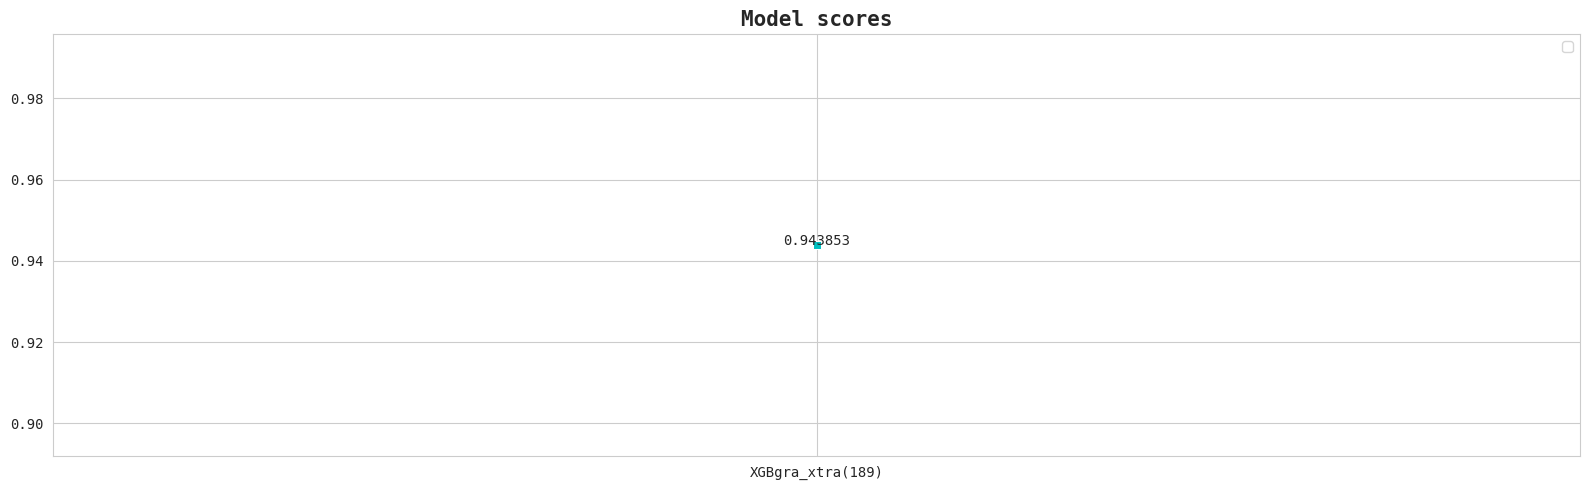

In [39]:
all_scores = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == "score":
            all_scores[k] = y

plt.figure(figsize=(16, 5))
ax1 = sns.lineplot([*all_scores.values()], marker="s")

y_add = 1e-6

for i, s1 in enumerate([*all_scores.values()]):
    ax1.text(float(i), s1+y_add, s1, ha="center", va="baseline")

# plt.ylim((0.96, 0.97))
plt.legend(loc="best")
plt.xticks(range(len(all_scores)), [*all_scores.keys()], rotation=0)
plt.title("Model scores", fontdict={"weight": "semibold", "size": 15})

plt.tight_layout()
plt.show()

In [40]:
# plot_feature_importances(max_cols=20)

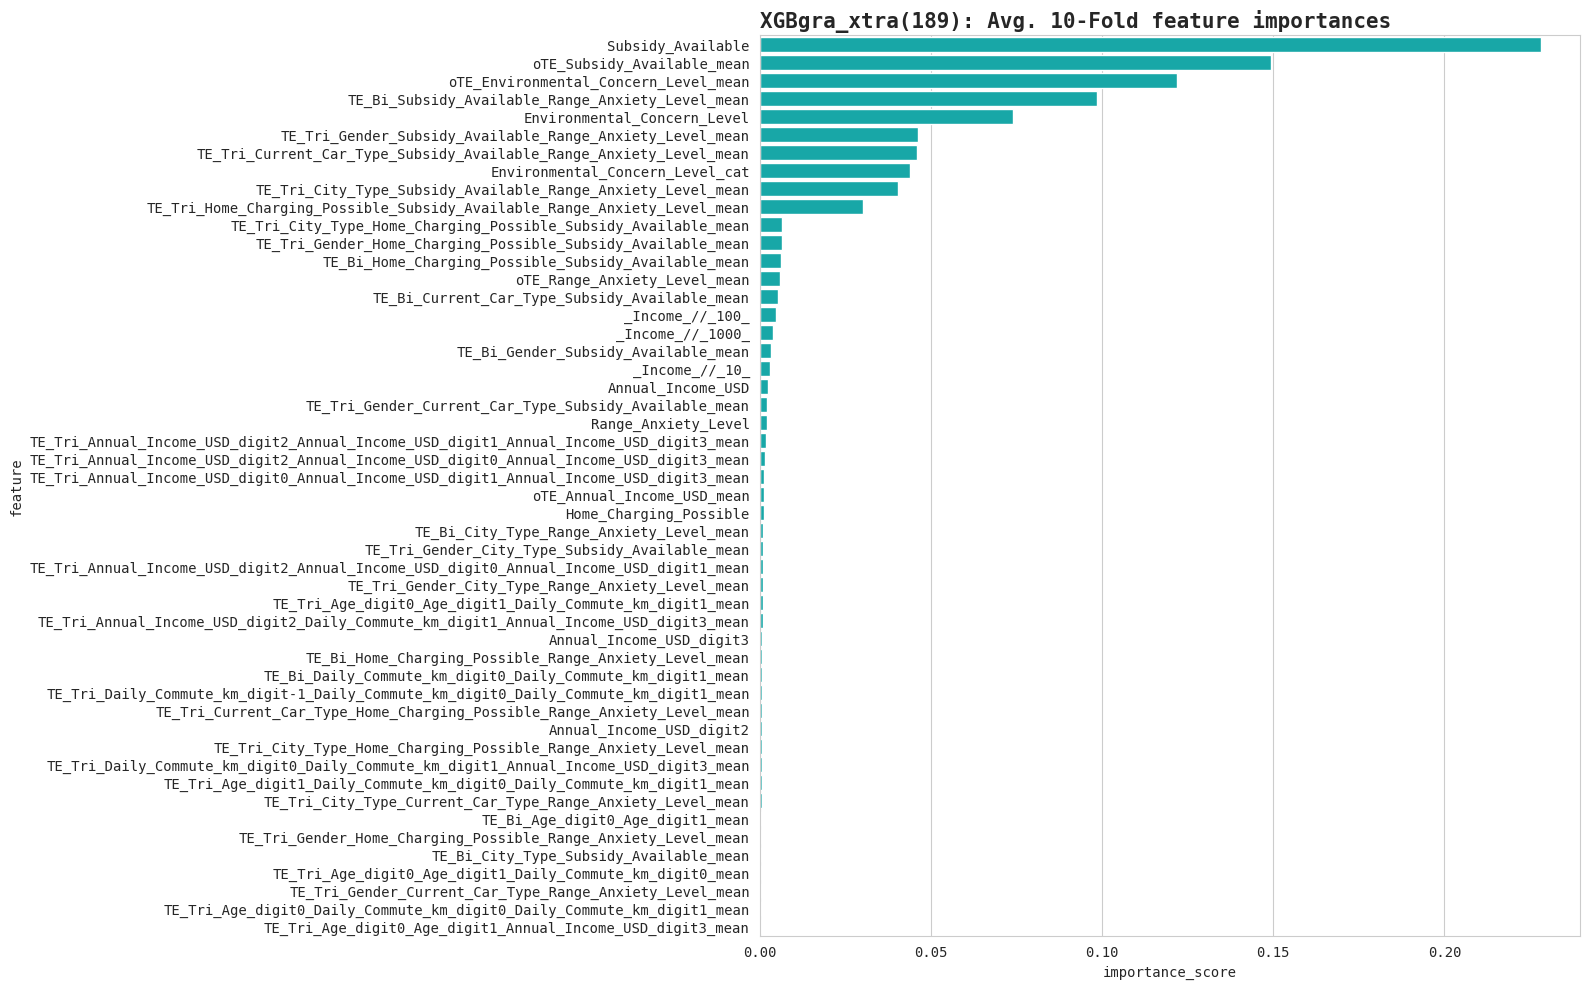

In [41]:
all_importances = {}
all_val_data = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == "importances":
            all_importances[k] = np.mean(y, axis=0)
        elif x == "val_data":
            all_val_data[k] = y # -> [0] select X_val, [1] select y_valid

top_n = 50

for i, (m, fi) in enumerate(all_importances.items()):
    fi_df = pd.DataFrame({
        "feature": all_val_data[m][0].columns,
        "importance_score": fi,
    }).sort_values(by="importance_score", ascending=False).reset_index(drop=True)
    
    plt.figure(figsize=(16, len(all_importances)*10))
    plt.subplot(len(all_importances), 1, i+1)
    sns.barplot(data=fi_df.head(top_n), x="importance_score", y="feature")
    plt.title(f"{m}: Avg. {FOLDS}-Fold feature importances", size=15, weight="semibold", loc='left')

    plt.tight_layout() 
    plt.show()

    print()

XGBgra_xtra(189)_943853 saved!


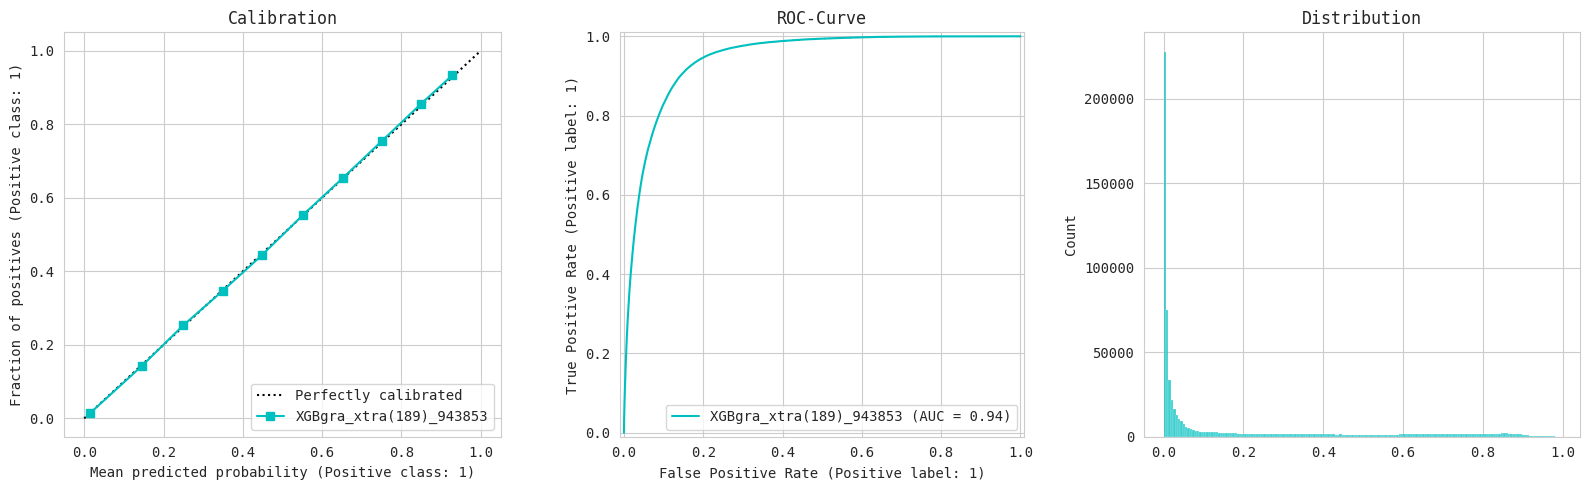

In [42]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, data_ in v.items():
        if key_ == "oof_preds":
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f"{n} saved!")

            ## -- Plot distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5))
            CalibrationDisplay.from_predictions(train_X[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title("Calibration")

            RocCurveDisplay.from_predictions(train_X[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title("ROC-Curve")

            sns.histplot(data_, ax=axs[2])
            axs[2].set_title("Distribution")

            plt.tight_layout()
            plt.show()

            print()

In [43]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submission[TARGET] = y
            submission.to_csv(f"submit_{n}.csv", index=False)
            print(f"{n} saved! {y.shape}")

            model_results[n[:-6]] = y

print()
model_results = pd.DataFrame(model_results)
model_results

XGBgra_xtra(189)_943853 saved! (286571,)



,XGBgra_xtra(189)_
0,0.009582
1,0.020188
2,0.038026
3,0.005848
4,0.009069
...,...
286566,0.000318
286567,0.058761
286568,0.002667
286569,0.001033


In [44]:
if len(model_results.columns) > 1:
    # display(model_results.corr("spearman"))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(model_results.corr("spearman"), annot=True, fmt=".4g", cbar=False, ax=ax1)
    ax1.set_title('Heatmap Correlation (Spearman)', fontsize=14, fontweight='bold')

    sns.ecdfplot(data=model_results, linewidth=2, ax=ax2)
    ax2.set_title('CDF Comparison of 5 Probability Distributions', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Probability Value', fontsize=12)
    ax2.set_ylabel('Cumulative Proportion (CDF)', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [45]:
# !rm -r /kaggle/working